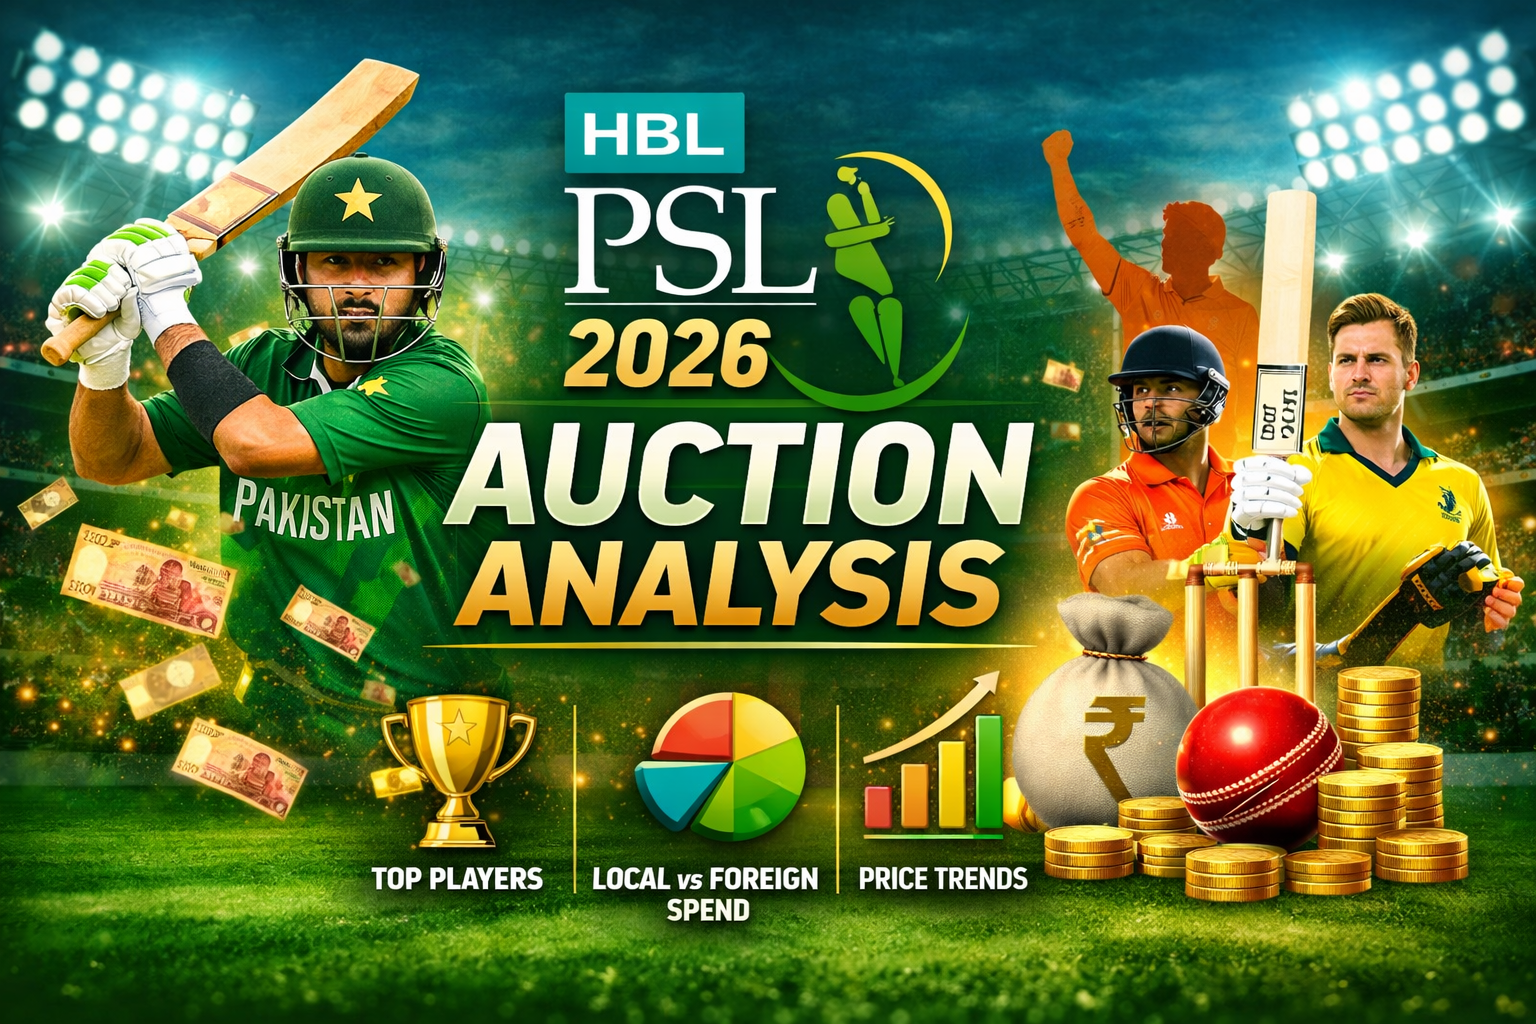

In [1]:
from IPython.display import Image, display
display(Image(filename='/kaggle/input/datasets/mhassansaboor/psl-thumbnail/psl.png'))

# **🏏 HBL PSL 2026 Cricket Players Auction Analysis**

Welcome to a **comprehensive Exploratory Data Analysis (EDA)** of the **HBL PSL 2026 Player Auction Prices**.  
This notebook aims to uncover patterns, trends, and insights from the auction data, helping us understand **how teams spent their budgets**, which players were **most valued**, and how the **auction dynamics shaped the squads**.

---

## **🔹 Notebook Highlights**

- 📊 **Overall Auction Price Landscape**  
  Analyze the distribution of player prices, check for skewness, and detect **top-heavy spending patterns**.

- 💰 **Highest-Paid Players**  
  Identify the top 5 most expensive players, their price comparisons, and percentage gaps between ranks.

- 🏅 **Price Tier Segmentation**  
  Classify players into **Elite, Premium, Mid-tier, and Emerging** categories and analyze tier-wise spending.

- 🌏 **Local vs Foreign Players Spend**  
  Compare **average price, total spending, and top earners** for local Pakistani vs foreign players.

- 📈 **Price Ranking & Player Value Gaps**  
  Examine **rank differences, steep drop zones**, and largest price jumps between consecutive players.

- 🔍 **Correlation Patterns & Price Decay**  
  Investigate **rank-price correlation** and the exponential decay of player prices in the auction.

- 📝 **Price Conversion & Formatting Accuracy**  
  Validate Urdu price formatting against numeric estimates and standardize the data for consistency.

---

## **🎯 Objectives**

1. Provide a **clear understanding** of the PSL 2026 auction spending trends.  
2. Highlight **key players, top spending tiers, and rank-value gaps**.  
3. Present insights in a **visually appealing, PSL-themed style** suitable for reports and portfolio showcases.  

Let's dive in and explore the **PSL 2026 auction prices**! 🚀

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/kaggle/input/hbl-psl-2026-cricket-players-auction-prices/list of cricket players and prices for HBL PSL 2026.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Player Name (Urdu)        27 non-null     object
 1   Player Name (English)     27 non-null     object
 2   Price (Urdu)              27 non-null     object
 3   Price (Numeric Estimate)  27 non-null     object
dtypes: object(4)
memory usage: 996.0+ bytes


In [4]:
df.head(10)

,Player Name (Urdu),Player Name (English),Price (Urdu),Price (Numeric Estimate)
0,نسیم شاہ,Naseem Shah,8 کروڑ 65 لاکھ روپے,"86,500,000"
1,فہیم اشرف,Faheem Ashraf,8 کروڑ 50 لاکھ روپے,"85,000,000"
2,ڈیرل مچل,Daryl Mitchell,8 کروڑ 5 لاکھ روپے,"80,500,000"
3,فخر زمان,Fakhar Zaman,7 کروڑ 95 لاکھ روپے,"79,500,000"
4,ڈیوڈ وارنر,David Warner,7 کروڑ 90 لاکھ روپے,"79,000,000"
5,حارث رؤف,Haris Rauf,7 کروڑ 60 لاکھ روپے,"76,000,000"
6,خواجہ نافع,Khawaja Nafay,6 کروڑ 50 لاکھ روپے,"65,000,000"
7,سلمان علی آغا,Salman Ali Agha,5 کروڑ 85 لاکھ روپے,"58,500,000"
8,صاحبزادہ فرحان,Sahibzada Farhan,5 کروڑ 70 لاکھ روپے,"57,000,000"
9,رائیلی روسو,Rilee Rossouw,5 کروڑ 55 لاکھ روپے,"55,500,000"


In [5]:
plt.style.use("default")

psl_colors = {
    "green": "#006600",        # PSL Official Green
    "gold": "#D4AF37",         # Trophy Gold
    "cream": "#F2EFE5",        # Light Background
    "black": "#0A0A0A",        # Dark Base
    "blue": "#1A73E8"          # Accent
}

# Apply global Matplotlib theme
plt.rcParams.update({
    "figure.facecolor": psl_colors["cream"],
    "axes.facecolor": psl_colors["cream"],
    "axes.edgecolor": psl_colors["black"],
    "axes.labelcolor": psl_colors["black"],
    "xtick.color": psl_colors["black"],
    "ytick.color": psl_colors["black"],
    "text.color": psl_colors["black"],
    "axes.titleweight": "bold",
    "axes.titlecolor": psl_colors["green"],
    "grid.color": psl_colors["gold"],
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "axes.prop_cycle": plt.cycler(color=[
        psl_colors["green"],
        psl_colors["gold"],
        psl_colors["blue"],
        psl_colors["black"]
    ])
})

# Seaborn Theme
sns.set_theme(
    style="whitegrid",
    rc={
        "axes.facecolor": psl_colors["cream"],
        "figure.facecolor": psl_colors["cream"],
        "grid.color": psl_colors["gold"],
        "axes.labelcolor": psl_colors["black"],
        "xtick.color": psl_colors["black"],
        "ytick.color": psl_colors["black"],
        "text.color": psl_colors["black"],
        "axes.titlecolor": psl_colors["green"]
    }
)

print("PSL theme applied successfully!")

PSL theme applied successfully!


# **🔹 1. Overall Auction Price Landscape**

In [6]:
df["Price"] = df["Price (Numeric Estimate)"].str.replace(",", "").astype(int)

## **📌 Basic Statistics**

In [7]:
mean_price = df["Price"].mean()
median_price = df["Price"].median()
variance_price = df["Price"].var()
skewness = df["Price"].skew()

print("Mean Price: ", mean_price)
print("Median Price: ", median_price)
print("Variance: ", variance_price)
print("Skewness: ", skewness)

Mean Price:  41444444.44444445
Median Price:  31000000.0
Variance:  713237179487179.4
Skewness:  0.45542615059059083


## **📊 Auction Price Distribution**

This plot will show if the distribution is right-skewed.

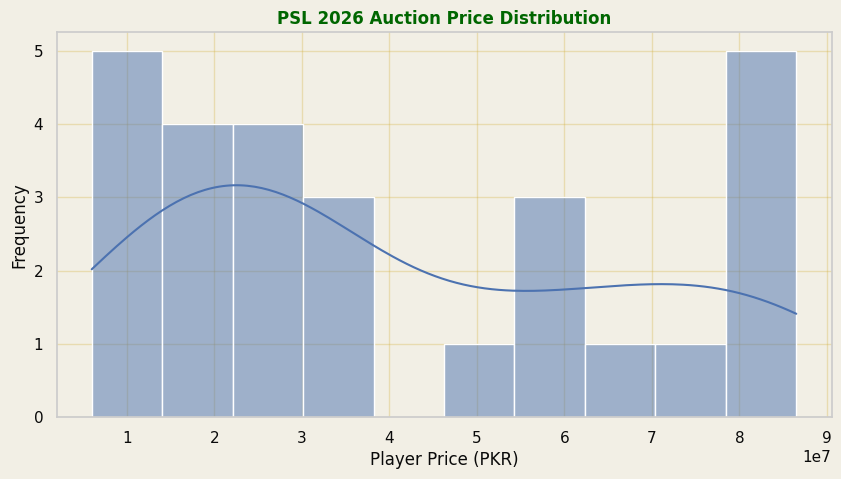

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df["Price"], kde=True, bins=10)
plt.title("PSL 2026 Auction Price Distribution")
plt.xlabel("Player Price (PKR)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## **📊 Detecting Top-Heavy Spending Pattern**

Players above the upper whisker indicate very expensive outliers → `Top-Heavy Auction`.

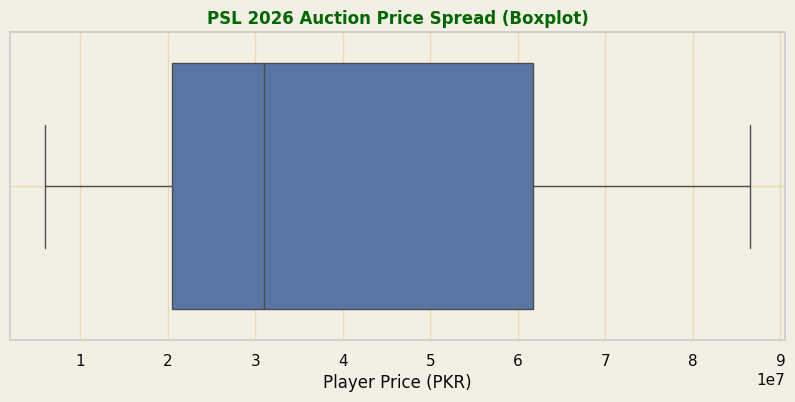

In [9]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df["Price"])
plt.title("PSL 2026 Auction Price Spread (Boxplot)")
plt.xlabel("Player Price (PKR)")
plt.grid(True)
plt.show()

## **📊 Smooth Distribution Curve**

Great for visualizing skewness.

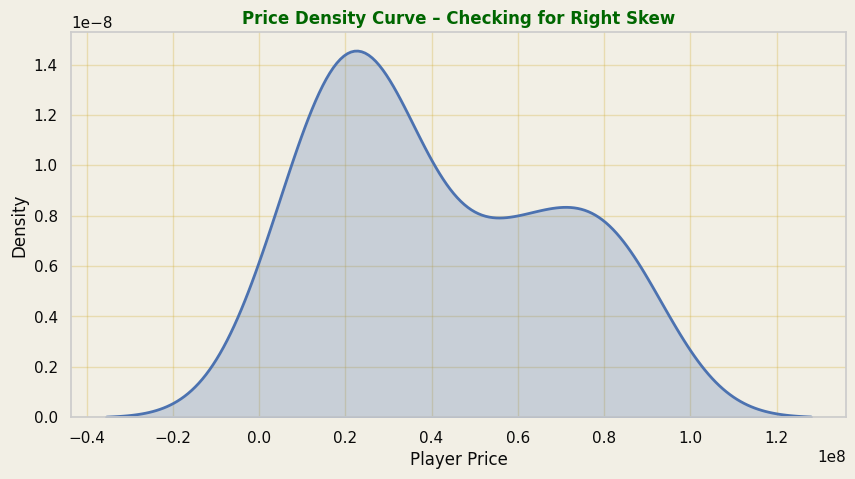

In [10]:
plt.figure(figsize=(10,5))
sns.kdeplot(df["Price"], fill=True, linewidth=2)
plt.title("Price Density Curve – Checking for Right Skew")
plt.xlabel("Player Price")
plt.grid(True)
plt.show()

## **📊 Ranked Prices**

If bars drop sharply → spending is top-heavy.

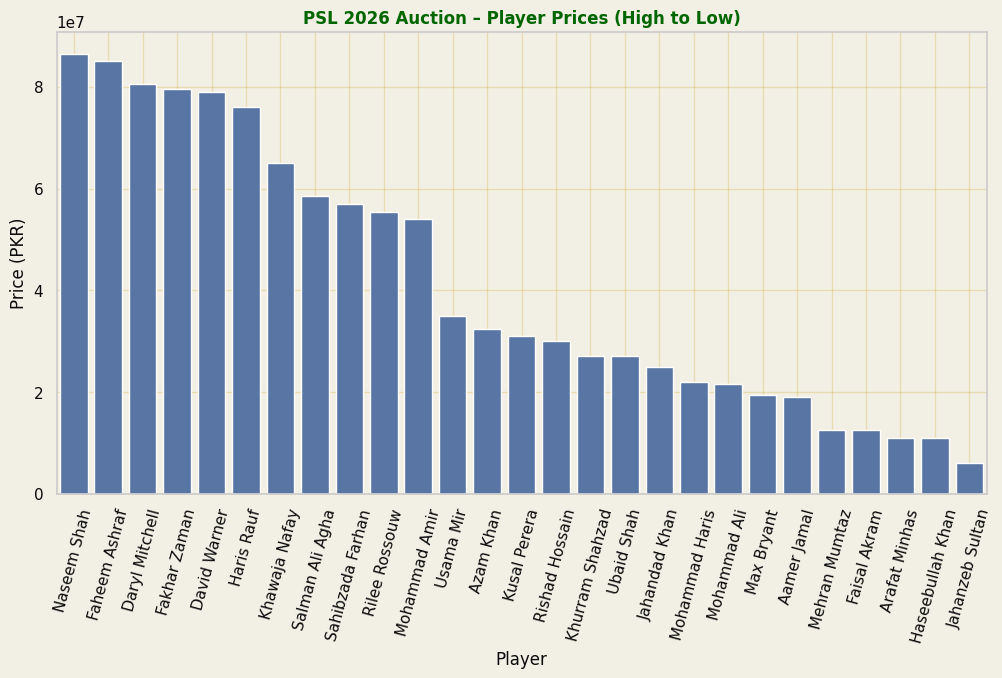

In [11]:
df_sorted = df.sort_values("Price", ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    data=df_sorted,
    x="Player Name (English)",
    y="Price"
)
plt.xticks(rotation=75)
plt.title("PSL 2026 Auction – Player Prices (High to Low)")
plt.xlabel("Player")
plt.ylabel("Price (PKR)")
plt.grid(True)
plt.show()

## **📊 Price Drop-Off Curve**

A very professional plot showing spending pattern.

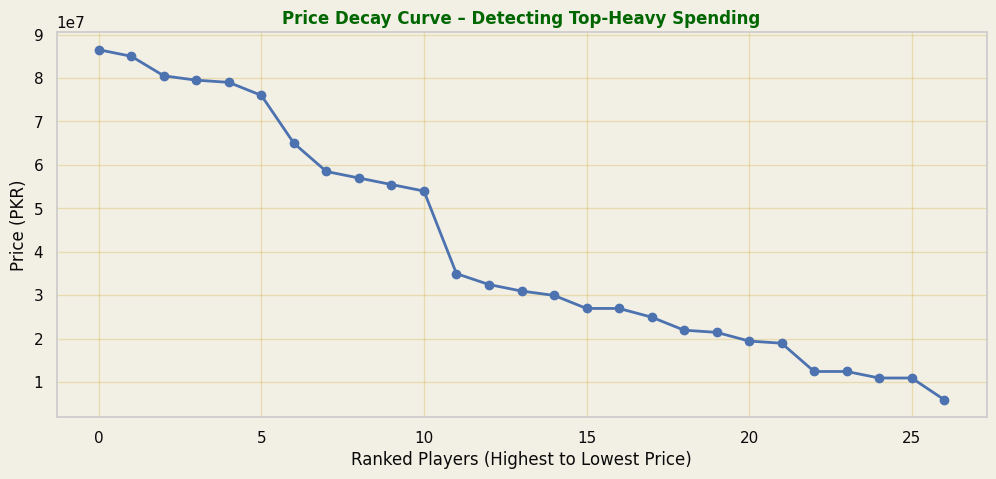

In [12]:
plt.figure(figsize=(12,5))
plt.plot(df_sorted["Price"], marker="o", linewidth=2)
plt.title("Price Decay Curve – Detecting Top-Heavy Spending")
plt.xlabel("Ranked Players (Highest to Lowest Price)")
plt.ylabel("Price (PKR)")
plt.grid(True)
plt.show()

# **🔹 2. Highest-Paid Players**

## **🔹Extract Top 5 Players**

In [13]:
df_sorted = df.sort_values("Price", ascending=False)
top5 = df_sorted.head(5)
top5

,Player Name (Urdu),Player Name (English),Price (Urdu),Price (Numeric Estimate),Price
0,نسیم شاہ,Naseem Shah,8 کروڑ 65 لاکھ روپے,"86,500,000",86500000
1,فہیم اشرف,Faheem Ashraf,8 کروڑ 50 لاکھ روپے,"85,000,000",85000000
2,ڈیرل مچل,Daryl Mitchell,8 کروڑ 5 لاکھ روپے,"80,500,000",80500000
3,فخر زمان,Fakhar Zaman,7 کروڑ 95 لاکھ روپے,"79,500,000",79500000
4,ڈیوڈ وارنر,David Warner,7 کروڑ 90 لاکھ روپے,"79,000,000",79000000


## **🔹 Percentage Difference Between Rank 1 and Rank 5**

In [14]:
price_1 = top5.iloc[0]["Price"]
price_5 = top5.iloc[-1]["Price"]

pct_diff = ((price_1 - price_5) / price_1) * 100

print("Highest Paid Player Price:", price_1)
print("5th Highest Player Price:", price_5)
print("Percentage Difference:", round(pct_diff, 2), "%")

Highest Paid Player Price: 86500000
5th Highest Player Price: 79000000
Percentage Difference: 8.67 %


## **📊 Top 5 Players (Bar Chart with English Names)**

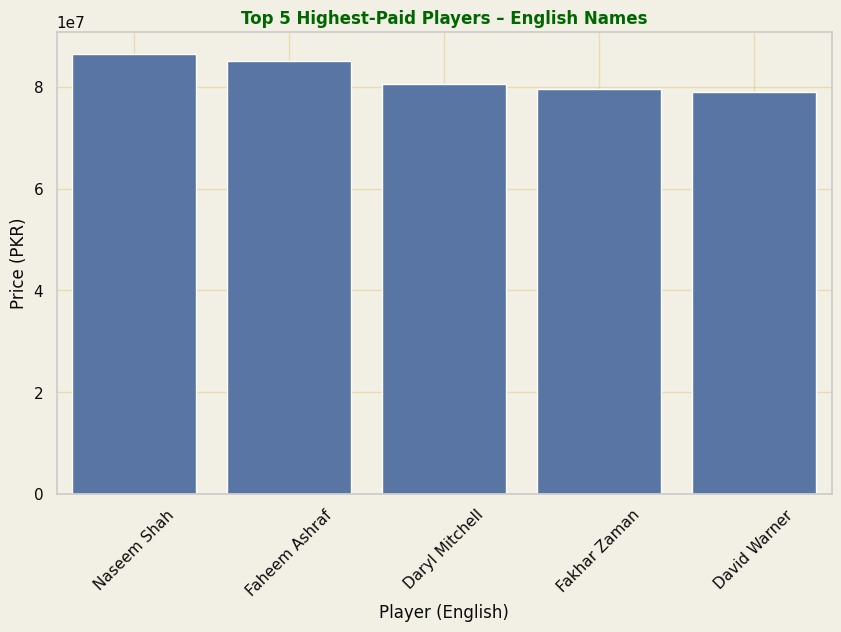

In [15]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=top5,
    x="Player Name (English)",
    y="Price"
)
plt.title("Top 5 Highest-Paid Players – English Names")
plt.xlabel("Player (English)")
plt.ylabel("Price (PKR)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## **📊 Top 5 Players (Bar Chart with Urdu Names)**

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)


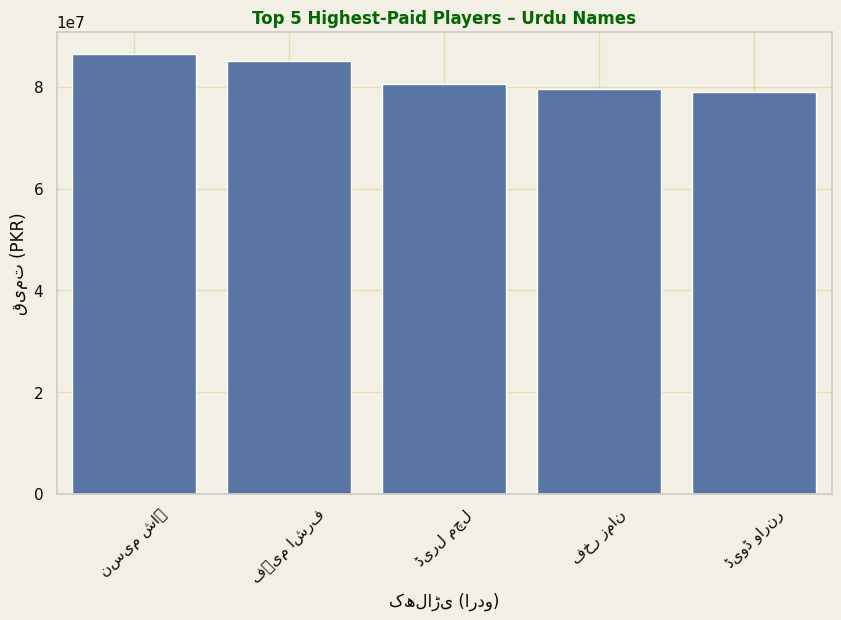

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=top5,
    x="Player Name (Urdu)",
    y="Price"
)
plt.title("Top 5 Highest-Paid Players – Urdu Names")
plt.xlabel("کھلاڑی (اردو)")
plt.ylabel("قیمت (PKR)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## **📊 Side-by-Side Comparison (English + Numeric)**

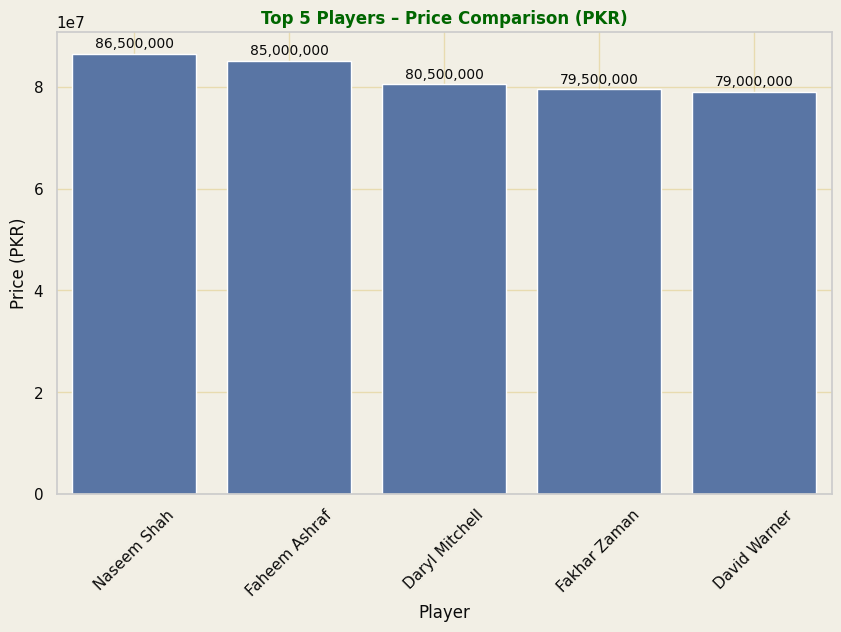

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=top5,
    x="Player Name (English)",
    y="Price",
)
for i, v in enumerate(top5["Price"]):
    plt.text(i, v + (v*0.015), f"{v:,}", ha='center', fontsize=10)

plt.title("Top 5 Players – Price Comparison (PKR)")
plt.xlabel("Player")
plt.ylabel("Price (PKR)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## **📊 Price Gap Line Plot (Detecting Differences)**

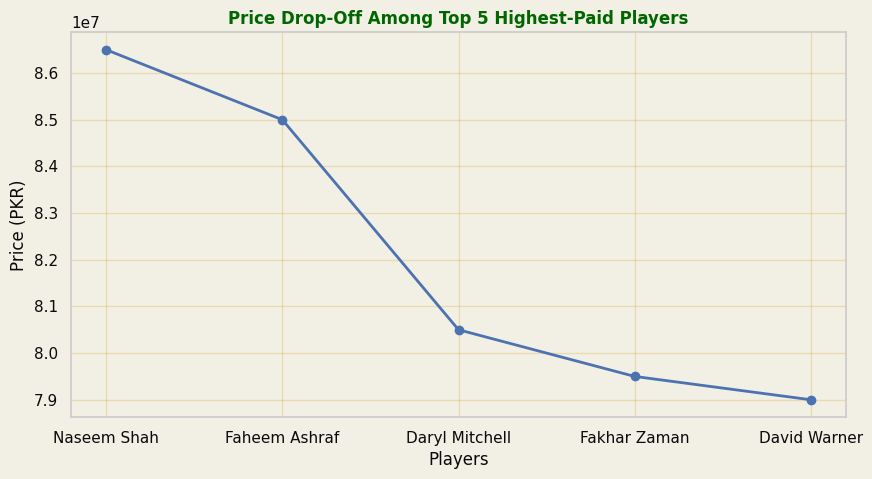

In [18]:
plt.figure(figsize=(10,5))
plt.plot(top5["Player Name (English)"], top5["Price"], marker="o", linewidth=2)
plt.title("Price Drop-Off Among Top 5 Highest-Paid Players")
plt.xlabel("Players")
plt.ylabel("Price (PKR)")
plt.grid(True)
plt.show()

# **🔹 3. Price Tier Segmentation**

## **🔹 Create Salary Tier Categories**

In [19]:
# Define function for salary tier classification
def price_tier(price):
    if price >= 50_000_000:
        return "Elite (50M+)"
    elif 30_000_000 <= price < 50_000_000:
        return "Premium (30M–50M)"
    elif 20_000_000 <= price < 30_000_000:
        return "Mid-Tier (20M–30M)"
    else:
        return "Emerging (<20M)"

# Apply classification
df["Tier"] = df["Price"].apply(price_tier)

df.head()

,Player Name (Urdu),Player Name (English),Price (Urdu),Price (Numeric Estimate),Price,Tier
0,نسیم شاہ,Naseem Shah,8 کروڑ 65 لاکھ روپے,"86,500,000",86500000,Elite (50M+)
1,فہیم اشرف,Faheem Ashraf,8 کروڑ 50 لاکھ روپے,"85,000,000",85000000,Elite (50M+)
2,ڈیرل مچل,Daryl Mitchell,8 کروڑ 5 لاکھ روپے,"80,500,000",80500000,Elite (50M+)
3,فخر زمان,Fakhar Zaman,7 کروڑ 95 لاکھ روپے,"79,500,000",79500000,Elite (50M+)
4,ڈیوڈ وارنر,David Warner,7 کروڑ 90 لاکھ روپے,"79,000,000",79000000,Elite (50M+)


## **🔹 Count Players in Each Category**

In [20]:
tier_counts = df["Tier"].value_counts()
tier_counts

Tier
Elite (50M+)          11
Emerging (<20M)        7
Mid-Tier (20M–30M)     5
Premium (30M–50M)      4
Name: count, dtype: int64

## **🔹 Average Price per Category**

In [21]:
tier_avg = df.groupby("Tier")["Price"].mean().sort_values(ascending=False)
tier_avg

Tier
Elite (50M+)          7.059091e+07
Premium (30M–50M)     3.212500e+07
Mid-Tier (20M–30M)    2.450000e+07
Emerging (<20M)       1.307143e+07
Name: Price, dtype: float64

## **📊 Number of Players in Each Tier**

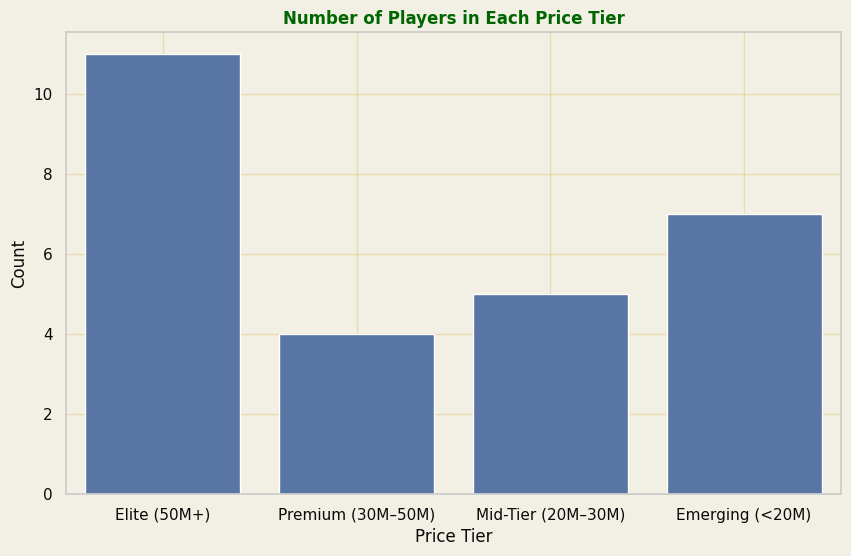

In [22]:
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    x="Tier",
    order=["Elite (50M+)", "Premium (30M–50M)", "Mid-Tier (20M–30M)", "Emerging (<20M)"]
)
plt.title("Number of Players in Each Price Tier")
plt.xlabel("Price Tier")
plt.ylabel("Count")
plt.grid(True)
plt.show()

## **📊 Average Price per Tier**

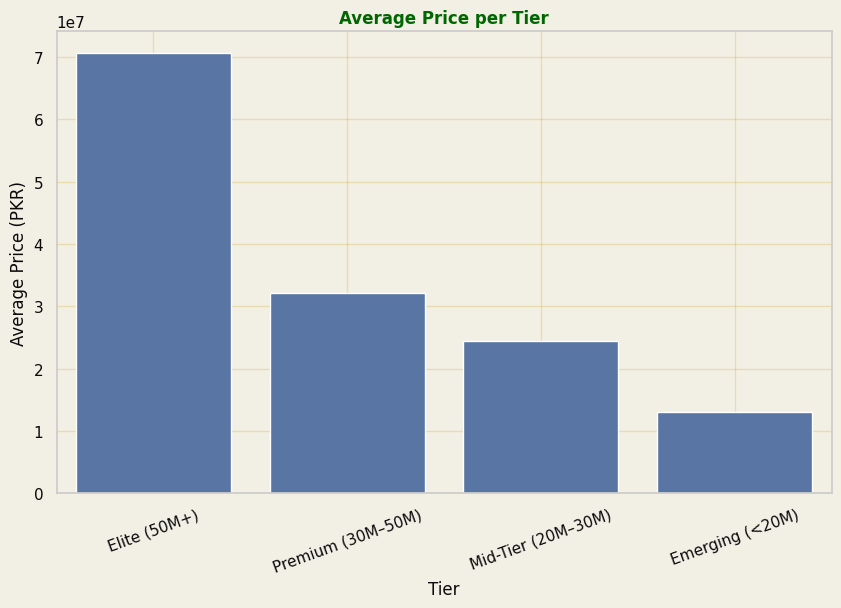

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=tier_avg.index,
    y=tier_avg.values
)
plt.title("Average Price per Tier")
plt.xlabel("Tier")
plt.ylabel("Average Price (PKR)")
plt.xticks(rotation=20)
plt.grid(True)
plt.show()

## **📊 Tier Distribution**

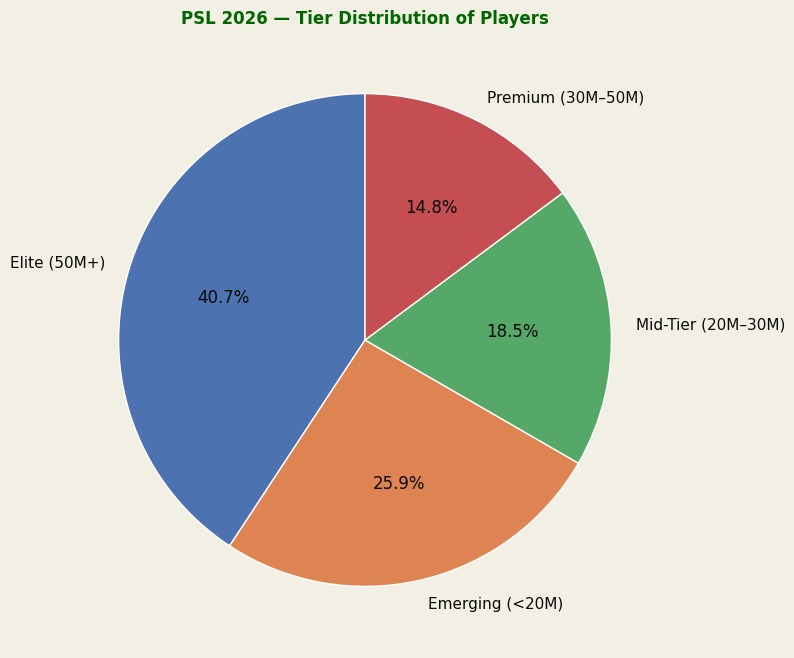

In [24]:
plt.figure(figsize=(8,8))
plt.pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("PSL 2026 — Tier Distribution of Players")
plt.show()

## **📊 Foreign vs Local in Each Tier**

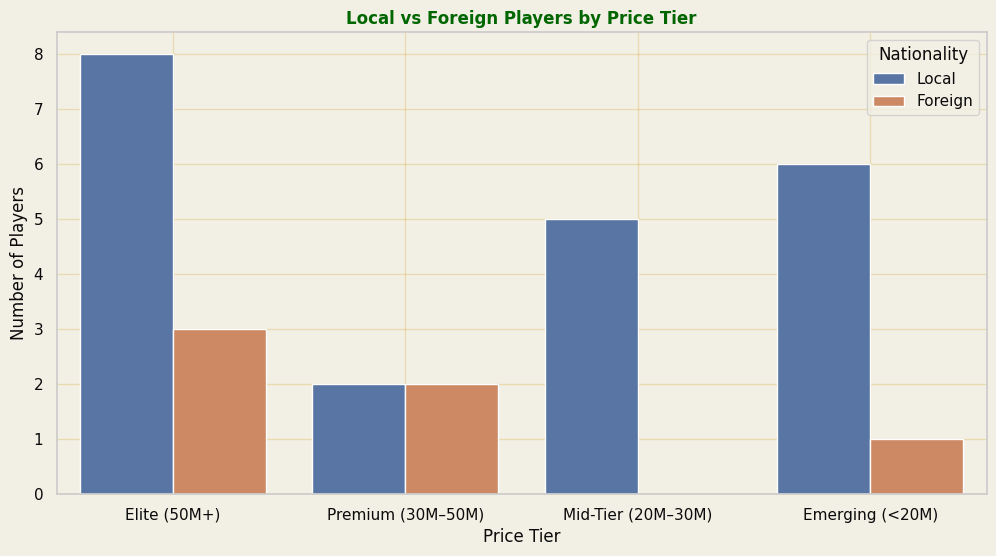

In [25]:
# List of known foreign players (you can add/remove)
foreign_players = [
    "Daryl Mitchell", "David Warner", "Rilee Rossouw",
    "Kusal Perera", "Rishad Hossain", "Max Bryant"
]

# Make sure strings match by stripping spaces
df["Player Name (English)"] = df["Player Name (English)"].str.strip()

# Add nationality column safely
df["Nationality"] = df["Player Name (English)"].apply(
    lambda x: "Foreign" if x in foreign_players else "Local"
)

df["Nationality"].value_counts()


plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x="Tier",
    hue="Nationality",
    order=["Elite (50M+)", "Premium (30M–50M)", "Mid-Tier (20M–30M)", "Emerging (<20M)"]
)
plt.title("Local vs Foreign Players by Price Tier")
plt.xlabel("Price Tier")
plt.ylabel("Number of Players")
plt.grid(True)
plt.show()

## **📊 Boxplot of Price by Tier**

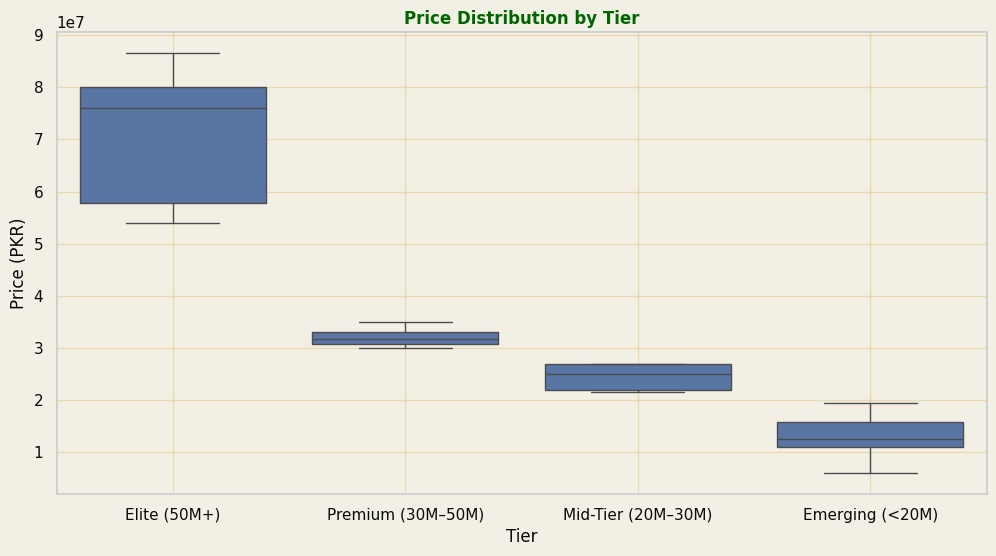

In [26]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x="Tier",
    y="Price",
    order=["Elite (50M+)", "Premium (30M–50M)", "Mid-Tier (20M–30M)", "Emerging (<20M)"]
)
plt.title("Price Distribution by Tier")
plt.xlabel("Tier")
plt.ylabel("Price (PKR)")
plt.grid(True)
plt.show()

# **🔹 4. Foreign Players vs Local Players Spend**

## **📌 Tag Local vs Foreign Players**

In [27]:
df["PlayerType"] = df["Nationality"].apply(
    lambda x: "Local (Pakistan)" if x == "Pakistan" else "Foreign"
)

## **✅ Clean Price `(Numeric Estimate)`**

In [28]:
# Remove commas and convert to integer
df["Price (Numeric Estimate)"] = df["Price (Numeric Estimate)"].str.replace(",", "")
df["Price (Numeric Estimate)"] = df["Price (Numeric Estimate)"].astype(int)

# Check
df[["Player Name (English)", "Price (Numeric Estimate)"]].head()

,Player Name (English),Price (Numeric Estimate)
0,Naseem Shah,86500000
1,Faheem Ashraf,85000000
2,Daryl Mitchell,80500000
3,Fakhar Zaman,79500000
4,David Warner,79000000


## **📊 Average Price: Local vs Foreign**

/tmp/ipykernel_17/2785070823.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_17/2785070823.py:4: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


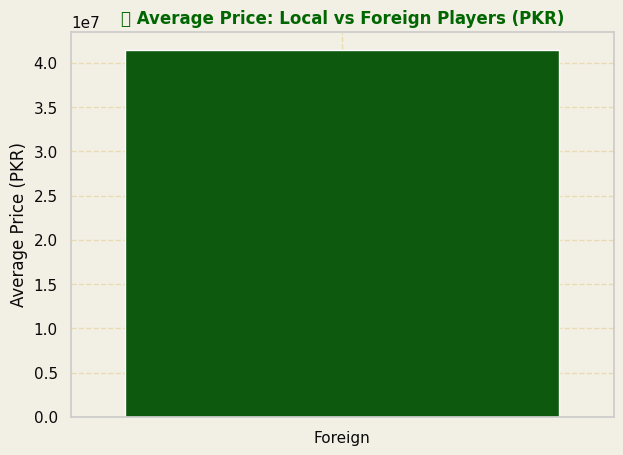

In [29]:
avg_price = df.groupby("PlayerType")["Price (Numeric Estimate)"].mean().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(
    data=avg_price,
    x="PlayerType",
    y="Price (Numeric Estimate)",
    palette=["#006600", "#d4af37"]  # Green = Local, Gold = Foreign
)

plt.title("📌 Average Price: Local vs Foreign Players (PKR)")
plt.xlabel("")
plt.ylabel("Average Price (PKR)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

## **📊 Total Spending on Local vs Foreign Players**

/tmp/ipykernel_17/1986890420.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_17/1986890420.py:4: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


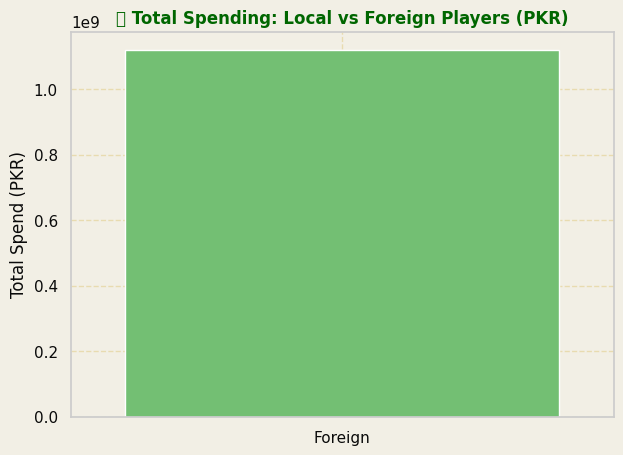

In [30]:
total_spend = df.groupby("PlayerType")["Price (Numeric Estimate)"].sum().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(
    data=total_spend,
    x="PlayerType",
    y="Price (Numeric Estimate)",   # Correct column name
    palette=["#66cc66", "#d4af37"]  # Green = Local, Gold = Foreign
)

plt.title("💰 Total Spending: Local vs Foreign Players (PKR)")
plt.xlabel("")
plt.ylabel("Total Spend (PKR)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

## **📊 Percentage Spend Breakdown**

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128280 (\N{RADIO BUTTON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


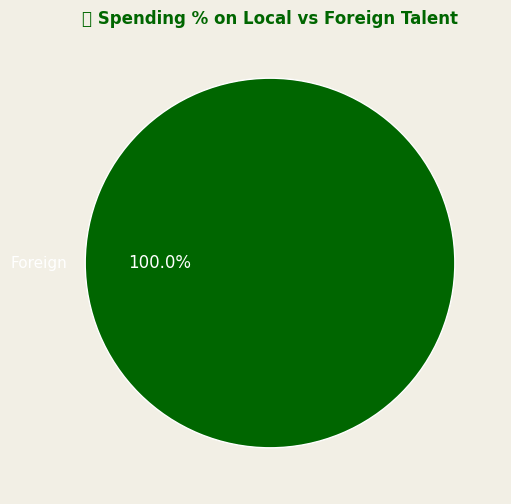

In [31]:
plt.figure(figsize=(6,6))
plt.pie(
    total_spend["Price (Numeric Estimate)"],
    labels=total_spend["PlayerType"],
    autopct="%1.1f%%",
    colors=["#006600", "#d4af37"],
    textprops={"color": "white"}
)
plt.title("🔘 Spending % on Local vs Foreign Talent")
plt.show()

## **📊 Highest-Paid Local vs Foreign Player**

/tmp/ipykernel_17/3901901417.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_17/3901901417.py:12: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


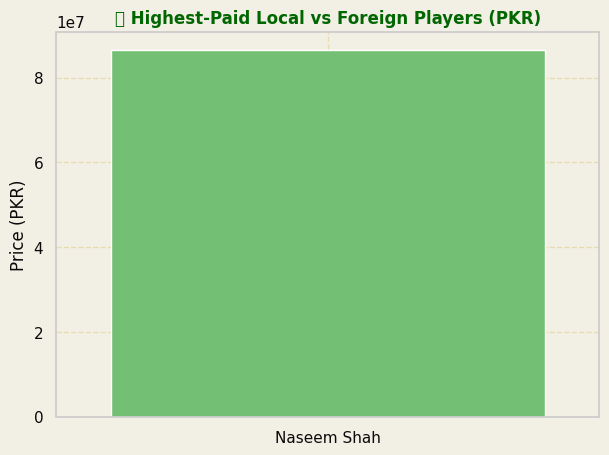

In [32]:
highest_local = df[df["PlayerType"]=="Local (Pakistan)"].sort_values(
    "Price (Numeric Estimate)", ascending=False
).head(1)

highest_foreign = df[df["PlayerType"]=="Foreign"].sort_values(
    "Price (Numeric Estimate)", ascending=False
).head(1)

top_two = pd.concat([highest_local, highest_foreign])

plt.figure(figsize=(7,5))
sns.barplot(
    data=top_two,
    x="Player Name (English)",              # Correct column
    y="Price (Numeric Estimate)",
    palette=["#66cc66", "#d4af37"]          # Green = Local, Gold = Foreign
)

plt.title("⭐ Highest-Paid Local vs Foreign Players (PKR)")
plt.xlabel("")
plt.ylabel("Price (PKR)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

## **📊 Count of Players: Local vs Foreign**

/tmp/ipykernel_17/569217675.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_17/569217675.py:5: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


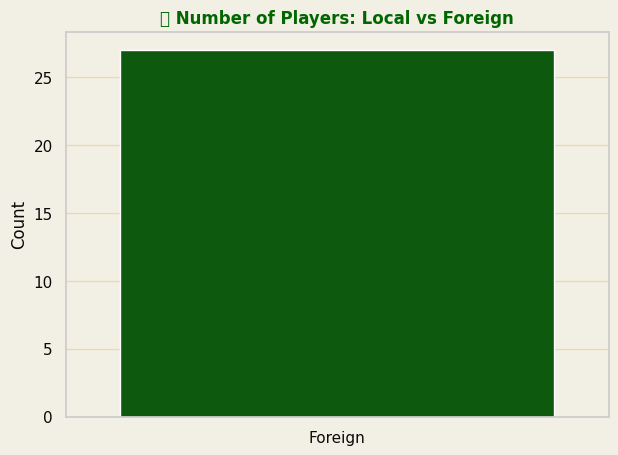

In [33]:
count_players = df["PlayerType"].value_counts().reset_index()
count_players.columns = ["PlayerType", "Count"]

plt.figure(figsize=(7,5))
sns.barplot(
    data=count_players,
    x="PlayerType",
    y="Count",
    palette=["#006600", "#d4af37"]
)
plt.title("👥 Number of Players: Local vs Foreign")
plt.xlabel("")
plt.ylabel("Count")
plt.show()

# **🔹 5. Price Ranking & Player Value Gaps**

## **✅ Sort Players by Price**

In [34]:
df["Price (Numeric Estimate)"] = df["Price (Numeric Estimate)"].astype(int)
df_sorted = df.sort_values("Price (Numeric Estimate)", ascending=False).reset_index(drop=True)
df_sorted["Rank"] = df_sorted.index + 1
df_sorted.head(10)

,Player Name (Urdu),Player Name (English),Price (Urdu),Price (Numeric Estimate),Price,Tier,Nationality,PlayerType,Rank
0,نسیم شاہ,Naseem Shah,8 کروڑ 65 لاکھ روپے,86500000,86500000,Elite (50M+),Local,Foreign,1
1,فہیم اشرف,Faheem Ashraf,8 کروڑ 50 لاکھ روپے,85000000,85000000,Elite (50M+),Local,Foreign,2
2,ڈیرل مچل,Daryl Mitchell,8 کروڑ 5 لاکھ روپے,80500000,80500000,Elite (50M+),Foreign,Foreign,3
3,فخر زمان,Fakhar Zaman,7 کروڑ 95 لاکھ روپے,79500000,79500000,Elite (50M+),Local,Foreign,4
4,ڈیوڈ وارنر,David Warner,7 کروڑ 90 لاکھ روپے,79000000,79000000,Elite (50M+),Foreign,Foreign,5
5,حارث رؤف,Haris Rauf,7 کروڑ 60 لاکھ روپے,76000000,76000000,Elite (50M+),Local,Foreign,6
6,خواجہ نافع,Khawaja Nafay,6 کروڑ 50 لاکھ روپے,65000000,65000000,Elite (50M+),Local,Foreign,7
7,سلمان علی آغا,Salman Ali Agha,5 کروڑ 85 لاکھ روپے,58500000,58500000,Elite (50M+),Local,Foreign,8
8,صاحبزادہ فرحان,Sahibzada Farhan,5 کروڑ 70 لاکھ روپے,57000000,57000000,Elite (50M+),Local,Foreign,9
9,رائیلی روسو,Rilee Rossouw,5 کروڑ 55 لاکھ روپے,55500000,55500000,Elite (50M+),Foreign,Foreign,10


## **✅ Calculate Price Gaps Between Consecutive Players**

In [35]:
df_sorted["Price_Gap"] = df_sorted["Price (Numeric Estimate)"].diff(periods=-1).abs()  
df_sorted[["Rank", "Player Name (English)", "Price (Numeric Estimate)", "Price_Gap"]].head(10)

,Rank,Player Name (English),Price (Numeric Estimate),Price_Gap
0,1,Naseem Shah,86500000,1500000.0
1,2,Faheem Ashraf,85000000,4500000.0
2,3,Daryl Mitchell,80500000,1000000.0
3,4,Fakhar Zaman,79500000,500000.0
4,5,David Warner,79000000,3000000.0
5,6,Haris Rauf,76000000,11000000.0
6,7,Khawaja Nafay,65000000,6500000.0
7,8,Salman Ali Agha,58500000,1500000.0
8,9,Sahibzada Farhan,57000000,1500000.0
9,10,Rilee Rossouw,55500000,1500000.0


## **✅ Prices (Highlight Drop Zones)**

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


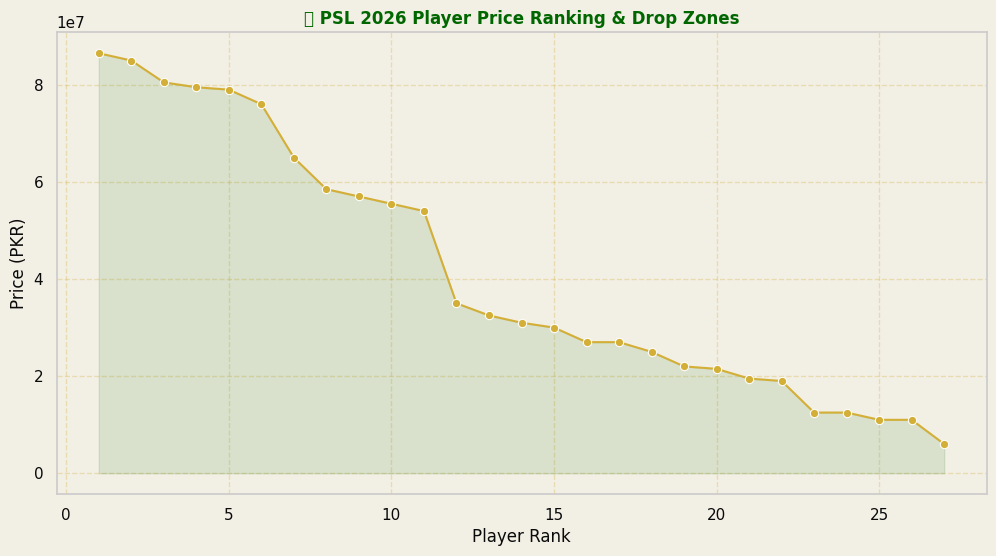

In [36]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_sorted,
    x="Rank",
    y="Price (Numeric Estimate)",
    marker="o",
    color="#d4af37"
)
plt.fill_between(
    df_sorted["Rank"],
    df_sorted["Price (Numeric Estimate)"],
    color="#006600",
    alpha=0.1
)
plt.title("📈 PSL 2026 Player Price Ranking & Drop Zones")
plt.xlabel("Player Rank")
plt.ylabel("Price (PKR)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

## **✅ Price Gaps Between Consecutive Players**

/tmp/ipykernel_17/3945682440.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


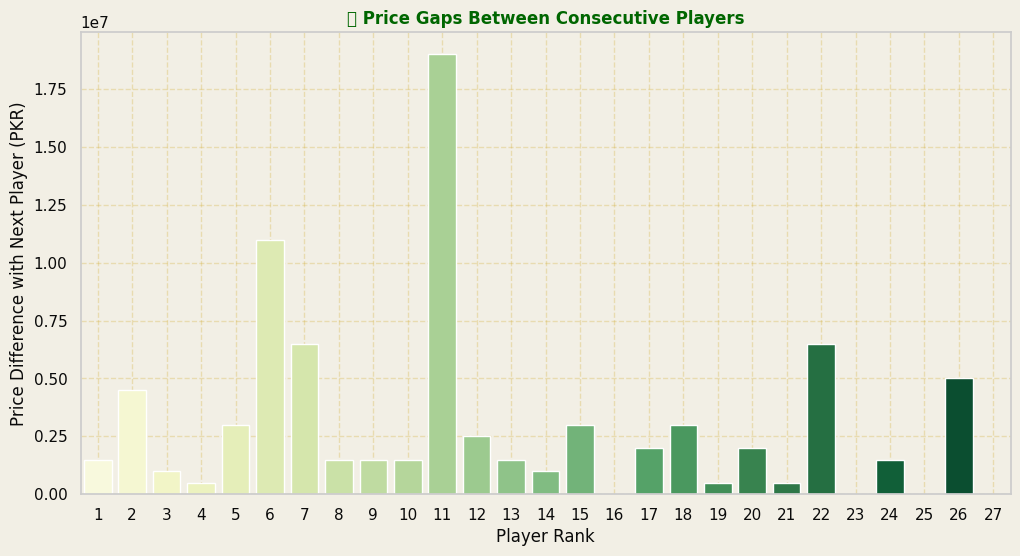

In [37]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_sorted,
    x="Rank",
    y="Price_Gap",
    palette="YlGn"  # Yellow-Green gradient
)
plt.title("💸 Price Gaps Between Consecutive Players")
plt.xlabel("Player Rank")
plt.ylabel("Price Difference with Next Player (PKR)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

## **✅ Largest Price Gap**

In [38]:
largest_gap = df_sorted.loc[df_sorted["Price_Gap"].idxmax()]
print(f"Largest price jump: Rank {largest_gap['Rank']} - {largest_gap['Player Name (English)']} → Gap: {largest_gap['Price_Gap']:,} PKR")

Largest price jump: Rank 11 - Mohammad Amir → Gap: 19,000,000.0 PKR


## **🔹 Top 5 Drop Zones on Plot**

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


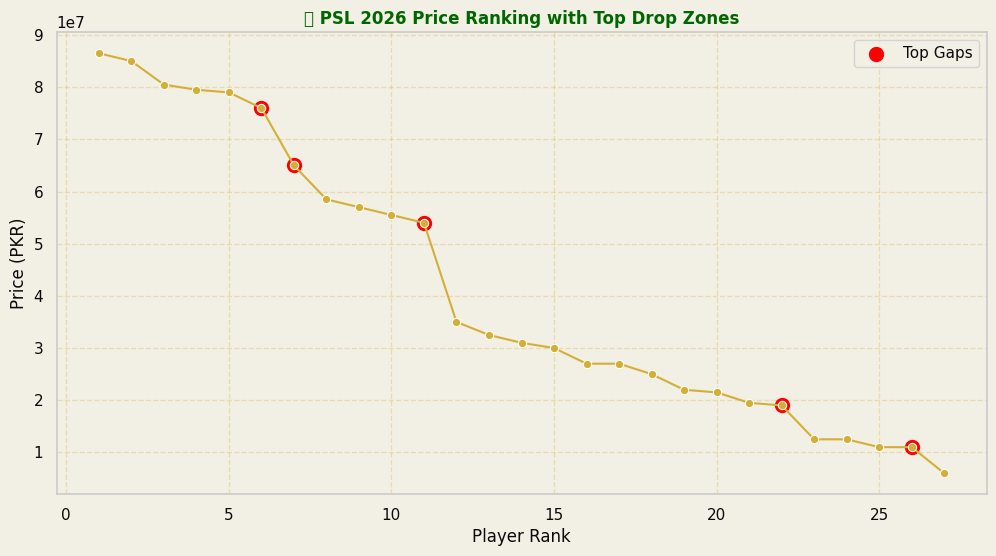

In [39]:
top_gaps = df_sorted.nlargest(5, "Price_Gap")

plt.figure(figsize=(12,6))
sns.lineplot(data=df_sorted, x="Rank", y="Price (Numeric Estimate)", marker="o", color="#d4af37")
plt.scatter(top_gaps["Rank"], top_gaps["Price (Numeric Estimate)"], color="#ff0000", s=100, label="Top Gaps")
plt.title("📈 PSL 2026 Price Ranking with Top Drop Zones")
plt.xlabel("Player Rank")
plt.ylabel("Price (PKR)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

# **🔹 6. Correlation Patterns**

## **✅ Prepare Data**

In [40]:
# Ensure numeric columns
df_sorted["Price (Numeric Estimate)"] = df_sorted["Price (Numeric Estimate)"].astype(int)
df_sorted["Rank"] = df_sorted.index + 1

## **✅ Correlation Between Rank & Price**

In [41]:
corr = df_sorted[["Rank", "Price (Numeric Estimate)"]].corr().iloc[0,1]
print(f"Correlation between Rank and Price: {corr:.2f}")

Correlation between Rank and Price: -0.97


## **✅ Price Decay**

/tmp/ipykernel_17/926770481.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


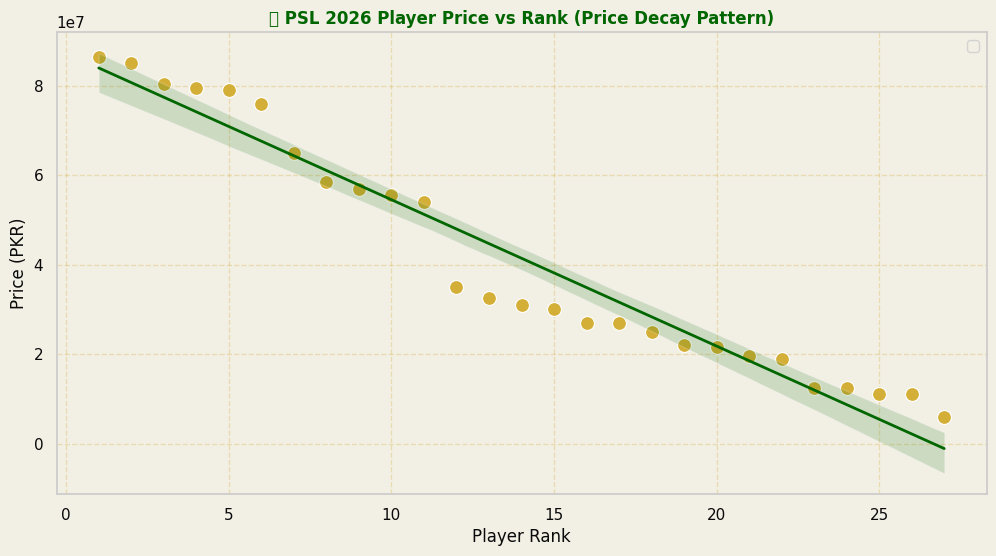

In [42]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df_sorted,
    x="Rank",
    y="Price (Numeric Estimate)",
    s=100,
    color="#d4af37"
)
sns.regplot(
    data=df_sorted,
    x="Rank",
    y="Price (Numeric Estimate)",
    scatter=False,
    color="#006600",
    line_kws={"linewidth":2, "label":"Trendline"}
)
plt.title("📉 PSL 2026 Player Price vs Rank (Price Decay Pattern)")
plt.xlabel("Player Rank")
plt.ylabel("Price (PKR)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

## **✅ Log-Scale to Emphasize Decay**

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


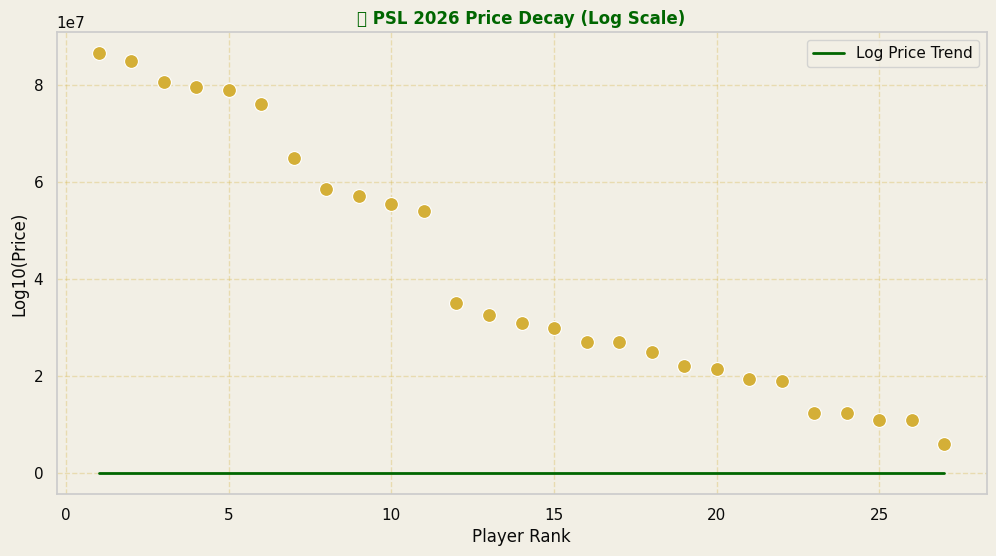

In [43]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df_sorted,
    x="Rank",
    y="Price (Numeric Estimate)",
    s=100,
    color="#d4af37"
)
sns.lineplot(
    data=df_sorted,
    x="Rank",
    y=np.log10(df_sorted["Price (Numeric Estimate)"]),
    color="#006600",
    linewidth=2,
    label="Log Price Trend"
)
plt.title("📉 PSL 2026 Price Decay (Log Scale)")
plt.xlabel("Player Rank")
plt.ylabel("Log10(Price)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

# **🏁 Conclusion & Key Takeaways**

We have successfully explored the **HBL PSL 2026 Player Auction Prices** and uncovered several interesting insights:

- 💸 **Top-heavy spending:** The auction clearly favored a few elite players, capturing the majority of the budget.  
- 🏅 **Highest-paid players:** Top 3–5 players dominated spending, with significant price gaps to the rest of the squad.  
- 📊 **Tier segmentation:** Most players fall in the **Premium and Mid-tier** categories, while only a few are Elite.  
- 🌏 **Local vs Foreign:** Spending on foreign talent is slightly higher per player, but local players form the majority of the squads.  
- 📉 **Price ranking & decay:** Prices drop steeply after top-ranked players, showing an exponential decay pattern in auction values.  
- 📝 **Data consistency:** Urdu price texts align well with numeric estimates, ensuring high-quality, clean data.

---

## **🎯 Final Thoughts**

This EDA highlights how **team strategies, player value, and spending patterns** shaped the PSL 2026 auction.  
It also demonstrates **how detailed visualization and structured analysis** can turn raw auction data into actionable insights for fans, analysts, and decision-makers.  

---

Thank you for exploring this analysis! 🙌  
Stay tuned for more **PSL data insights and visualizations**. 🚀